In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import seaborn as sns


plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [font for font in 'Liberation Sans, DejaVu Sans, Arial, Helvetica, Lucida Grande, Verdana, Geneva, Lucid, Avant Garde, sans-serif'.split(', ')] 
plt.rcParams['mathtext.fontset'] = 'stixsans'

plt.rcParams['axes.linewidth'] = 1
plt.rcParams['grid.linewidth'] = 1
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6



In [2]:
colors_list = [ '#263238','#2E5BFF', "#D4AF37", '#D81B60', '#558B2F', '#7B1FA2', '#E65100']  # ,   '#94A3B8' 
unique_categories = ['common',  'SADE unique', 'CR unique', 'TSS unique',  'SADE+CR, not TSS', 'SADE+TSS, not CR', 'CR+TSS, not SADE', ]


cat_colors_map = dict(zip(unique_categories, colors_list))                  
cat_labels_map = dict(zip(unique_categories, unique_categories))


jitter_width = 0.25
position_offset = [0] + [-jitter_width] * 3 + [jitter_width] * 3  # Adjust offsets for each category
cat_position_map = dict(zip(unique_categories, position_offset))

In [14]:
frip_names = [ 'cr_peaks',  'entropy_peaks', 'tsse_peaks',  'raw_peaks']
frip_col_names = [f'FRIP_' + col for col in frip_names]
frip_col_labels = ['Peak set from\nCR droplets', 'Peak set from\nSADE droplets', 'Peak set from\nTSSe droplets', 'Peak set from\nCommon droplets', 'Raw peaks from\nall reads']
frip_col_labels_map = dict(zip(frip_col_names, frip_col_labels))

In [15]:
SADEvsCR_unique_categoris = ['both', 'entropy_only', 'cr_only', 'none', 'tss_only']
SADEcsCR_labels = ['Overlap', 'SADE unique', 'CR unique', 'Neither', 'TSSe unique']
SADEvsCR_colors = ['#0C5B28', '#2E5BFF', '#F59E0B', '#94A3B8', '#D81B60']

SADEvsCR_colors_map = dict(zip(SADEvsCR_unique_categoris, SADEvsCR_colors))
SADEvsCR_label_map = dict(zip(SADEvsCR_unique_categoris, SADEcsCR_labels))

jitter_width = 0.25
SADEvsCR_position_offset = [0] + [-jitter_width] * 1 + [jitter_width] * 3  # Adjust offsets for each category
SADEvsCR_cat_position_map = dict(zip(SADEvsCR_unique_categoris, SADEvsCR_position_offset))

In [16]:
def add_jittered_points(ax, data_group, position, jitter_width=0.3, s = 15, alpha=0.5, color='orange', marker='*', edgecolors='none', lw=1):
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=alpha, s=s, zorder=1, marker=marker, lw=lw, edgecolors=edgecolors) # s controls point size


# Load data

In [6]:
# Load barcode dataframe 
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set.tsv')
union_cell_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)
union_cell_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,_3set_identified_by_atac,Entropy,DNA_debris,P_closed_state
atac_barcodes,,,,,,,,,,
AAACAAGCAAGTTAGT-1,2412,True,True,True,both,both,common,0.218328,NO,0.965116
AAACAAGCATTTCTTC-1,9030,True,True,True,both,both,common,0.074451,NO,0.990949


In [7]:
union_cell_info['_2set_identified_by_atac_SC_mod'] = union_cell_info['_2set_identified_by_atac_SC'].replace('none', 'tss_only')

In [9]:
# Load FRIP score corresponding to each peak-set 
frag_in_Raw_peak_file = os.path.join(Union_cell_subdir, 'Rawpeaks', 'frag_overlap/frag_in_peaks.tsv')

frag_in_Entropy_peak_file = os.path.join(Union_cell_subdir, 'Entropy_cells_peaks', 'frag_overlap/frag_in_peaks.tsv')
frag_in_TSSe_peak_file = os.path.join(Union_cell_subdir, 'TSS_cells_peaks', 'frag_overlap/frag_in_peaks.tsv')
frag_in_CR_peak_file = os.path.join(Union_cell_subdir, 'FRIP_cells_peaks', 'frag_overlap/frag_in_peaks.tsv')


frag_in_raw_peaks = pd.read_csv(frag_in_Raw_peak_file, sep='\t', index_col=3, header=None)
frag_in_entropy_peaks = pd.read_csv(frag_in_Entropy_peak_file, sep='\t', index_col=3, header=None)
frag_in_tsse_peaks = pd.read_csv(frag_in_TSSe_peak_file, sep='\t', index_col=3, header=None)
frag_in_cr_peaks = pd.read_csv(frag_in_CR_peak_file, sep='\t', index_col=3, header=None)


for df in [frag_in_raw_peaks, frag_in_entropy_peaks, frag_in_tsse_peaks, frag_in_cr_peaks]:
    df.index.name ='atac_BC'
    df.columns = ['chrom', 'start', 'end', 'support']
    df['atac_bc'] = df.index
    df['frag_length'] = df['end'] - df['start']

# FRIP on each peak-set comparision among 3 cell-calling approaches

## FRIP distribution

In [10]:
total_frag_per_bc = union_cell_info.copy()

for col, df in zip(['Nfrag_in_raw_peaks', 'Nfrag_in_entropy_peaks', 'Nfrag_in_tsse_peaks', 'Nfrag_in_cr_peaks'], 
               [frag_in_raw_peaks, frag_in_entropy_peaks, frag_in_tsse_peaks, frag_in_cr_peaks]):
    total_frag_per_bc[col] = total_frag_per_bc.index.map(df.groupby('atac_bc').size())
    frip_col_name = 'FRIP_' + col.split('_in_')[1]
    total_frag_per_bc[frip_col_name] = total_frag_per_bc[col] / total_frag_per_bc['total_fragments'] 


In [11]:
total_frag_per_bc.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,_3set_identified_by_atac,Entropy,DNA_debris,P_closed_state,_2set_identified_by_atac_SC_mod,Nfrag_in_raw_peaks,FRIP_raw_peaks,Nfrag_in_entropy_peaks,FRIP_entropy_peaks,Nfrag_in_tsse_peaks,FRIP_tsse_peaks,Nfrag_in_cr_peaks,FRIP_cr_peaks
atac_barcodes,,,,,,,,,,,,,,,,,,,
AAACAAGCAAGTTAGT-1,2412,True,True,True,both,both,common,0.218328,NO,0.965116,both,1729,0.716833,1919,0.795605,1933,0.801410,1785,0.740050
AAACAAGCATTTCTTC-1,9030,True,True,True,both,both,common,0.074451,NO,0.990949,both,1538,0.170321,1847,0.204540,1877,0.207863,1635,0.181063


In [12]:
frip_info_file = os.path.join(Union_cell_subdir, 'frip_cells_info.tsv')
total_frag_per_bc.to_csv(frip_info_file, sep='\t')

## comparing FRIP in each peak-set

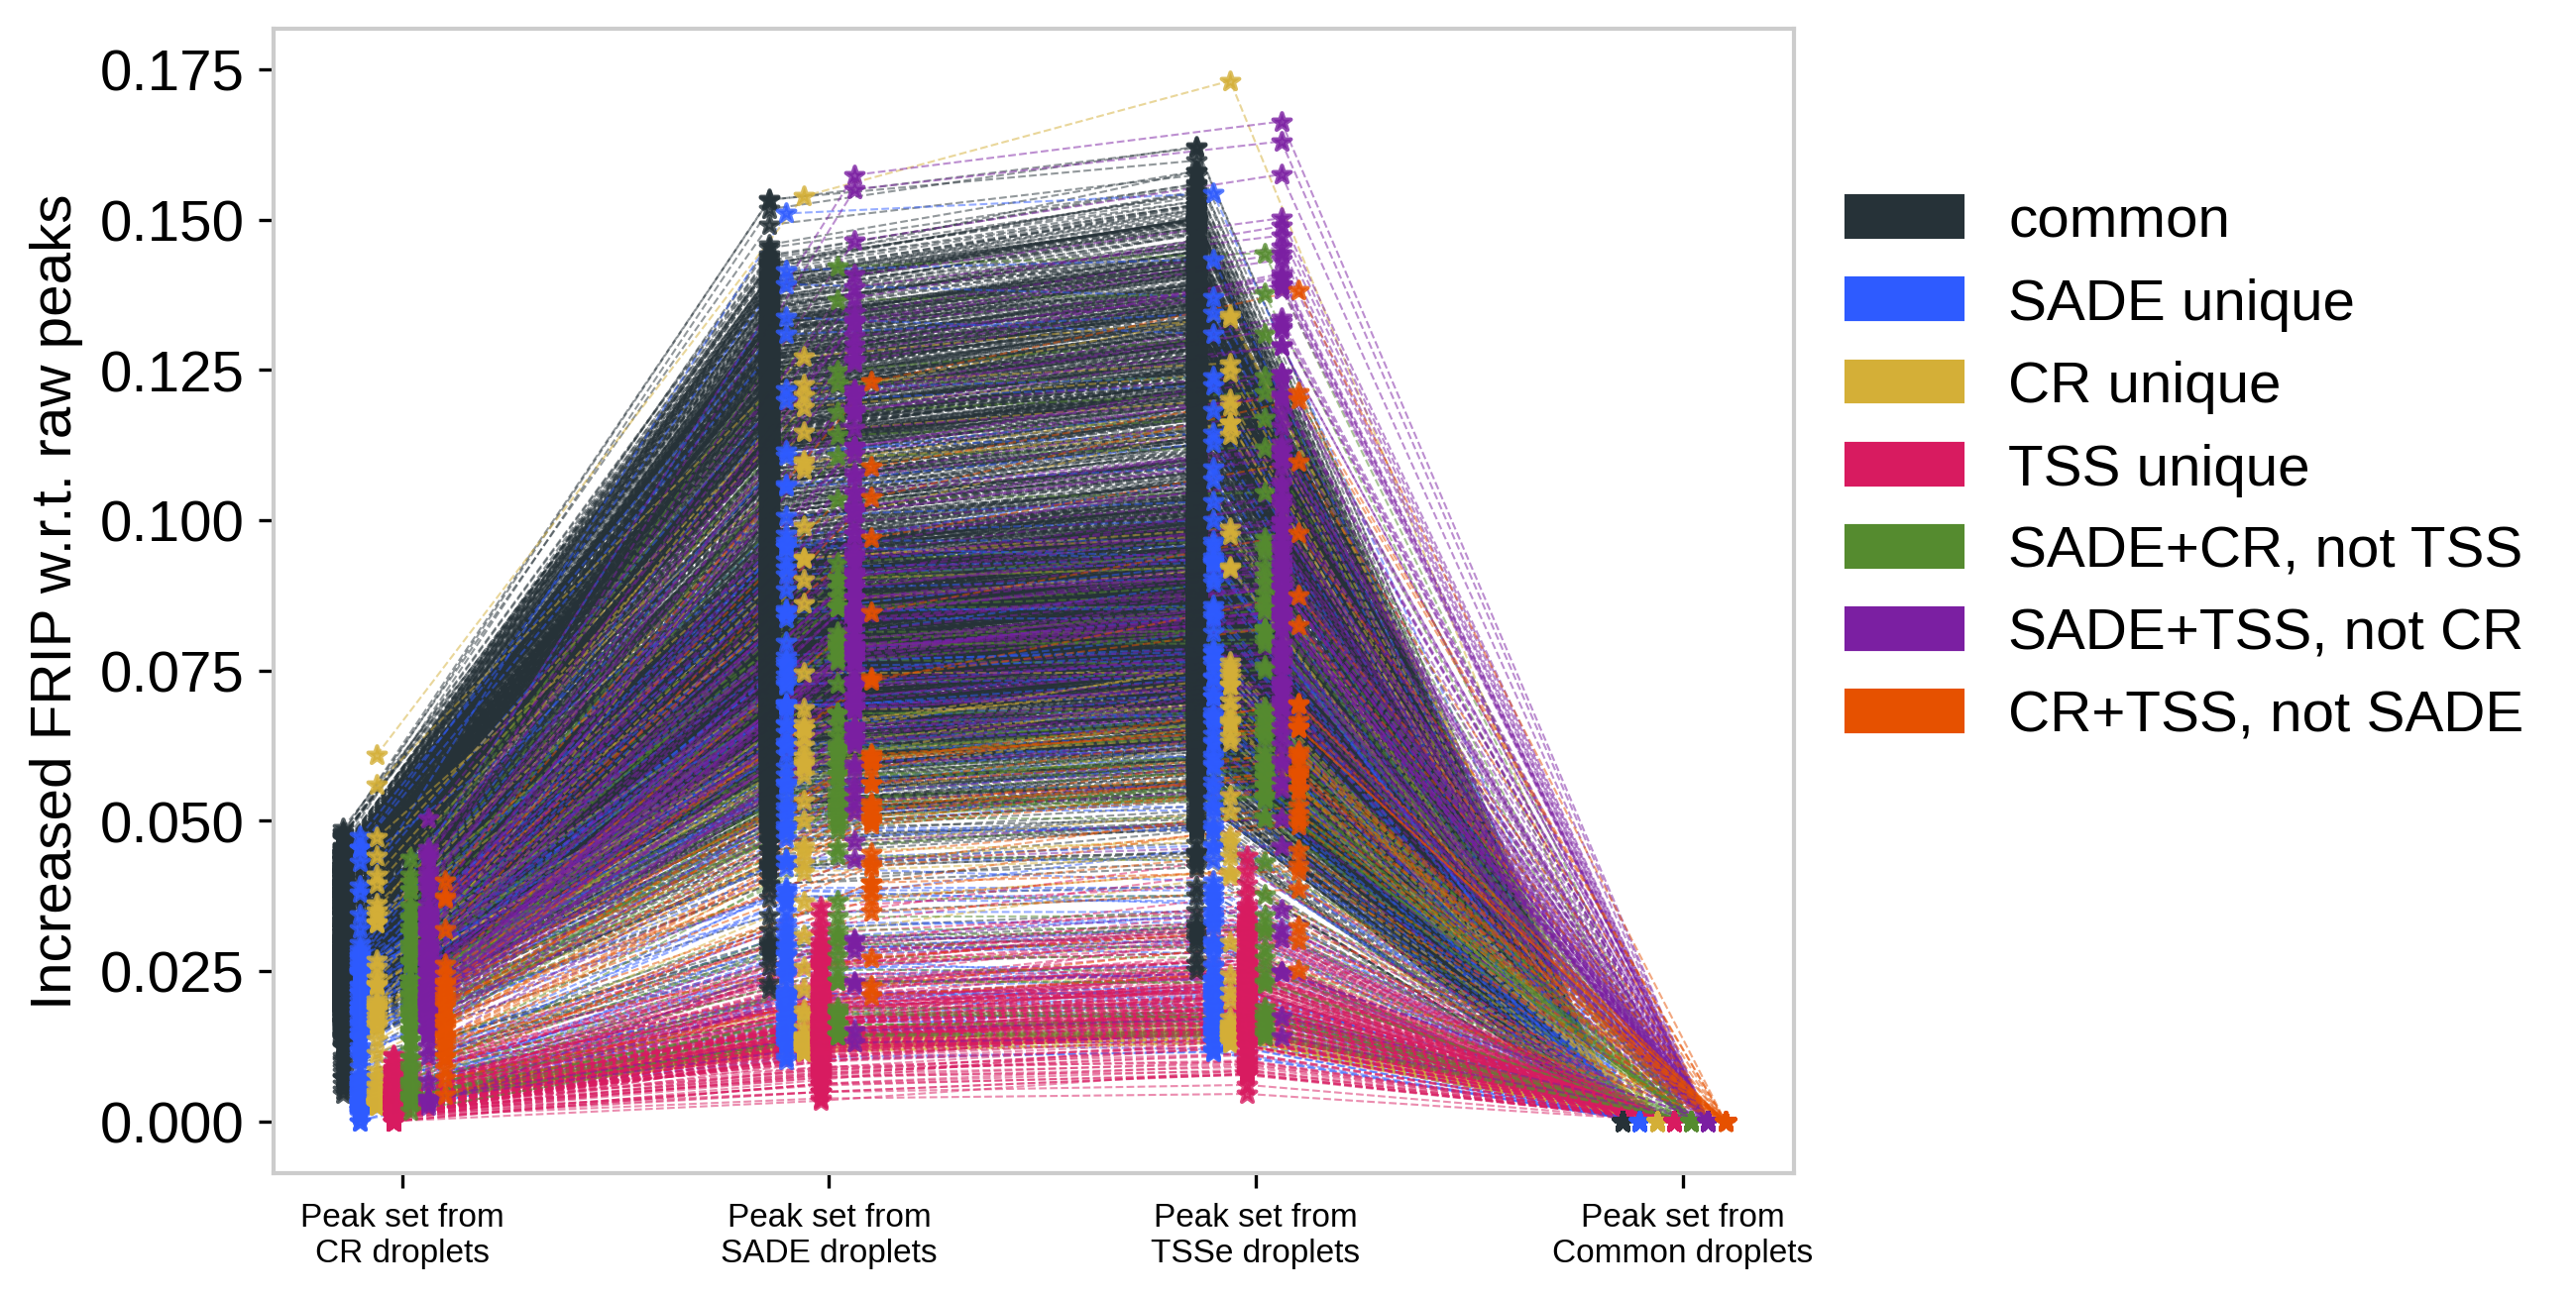

In [17]:
fig, ax = plt.subplots(ncols=1, figsize=(6.6, 5))

position_offset = 0.04 * (np.arange( len(unique_categories)) -  len(unique_categories)/2)  

for i, cat in enumerate(unique_categories):
    datapoints_index = total_frag_per_bc['_3set_identified_by_atac'] == cat
    color = cat_colors_map[cat]
    frip_diff = total_frag_per_bc.loc[datapoints_index, frip_col_names] - total_frag_per_bc.loc[datapoints_index, 'FRIP_raw_peaks'].values[:, None]
    # Plot the lines with x-position offset to avoid overlap
    _ = ax.plot(position_offset[i] + np.arange(len(frip_diff.T)), frip_diff.T, alpha=0.5, color=color,  markersize=4, linestyle='--', linewidth=0.5)
    # Enhance visibility of individual points by adding jittered scatter on top of the lines
    N_datapoints = frip_diff.shape[0]
    for j, col in enumerate(frip_col_names):
        _ = ax.scatter(np.repeat(position_offset[i] + j, N_datapoints), frip_diff.iloc[:, j], alpha=0.8, color=color, marker='*', s=20, zorder=3)

handles = [mpatches.Patch(color=cat_colors_map[cat], label=cat) for cat in unique_categories]
ax.legend(handles=handles, frameon=False, title='', bbox_to_anchor=(1., 0.9), loc='upper left')
ax.set_xticks(range(len(frip_col_names)))
ax.set_xticklabels([frip_col_labels_map[col] for col in frip_col_names], rotation=0, ha='center', fontsize=8)
ax.set_ylabel('Increased FRIP w.r.t. raw peaks')


for edge in ['top', 'right', 'left', 'bottom']:
    ax.spines[edge].set_color('#cccccc')


/tmp/ipykernel_2874173/1144141230.py:8: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[i].scatter(total_frag_per_bc[f'FRIP_{x}'],
/tmp/ipykernel_2874173/1144141230.py:8: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[i].scatter(total_frag_per_bc[f'FRIP_{x}'],
/tmp/ipykernel_2874173/1144141230.py:8: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[i].scatter(total_frag_per_bc[f'FRIP_{x}'],


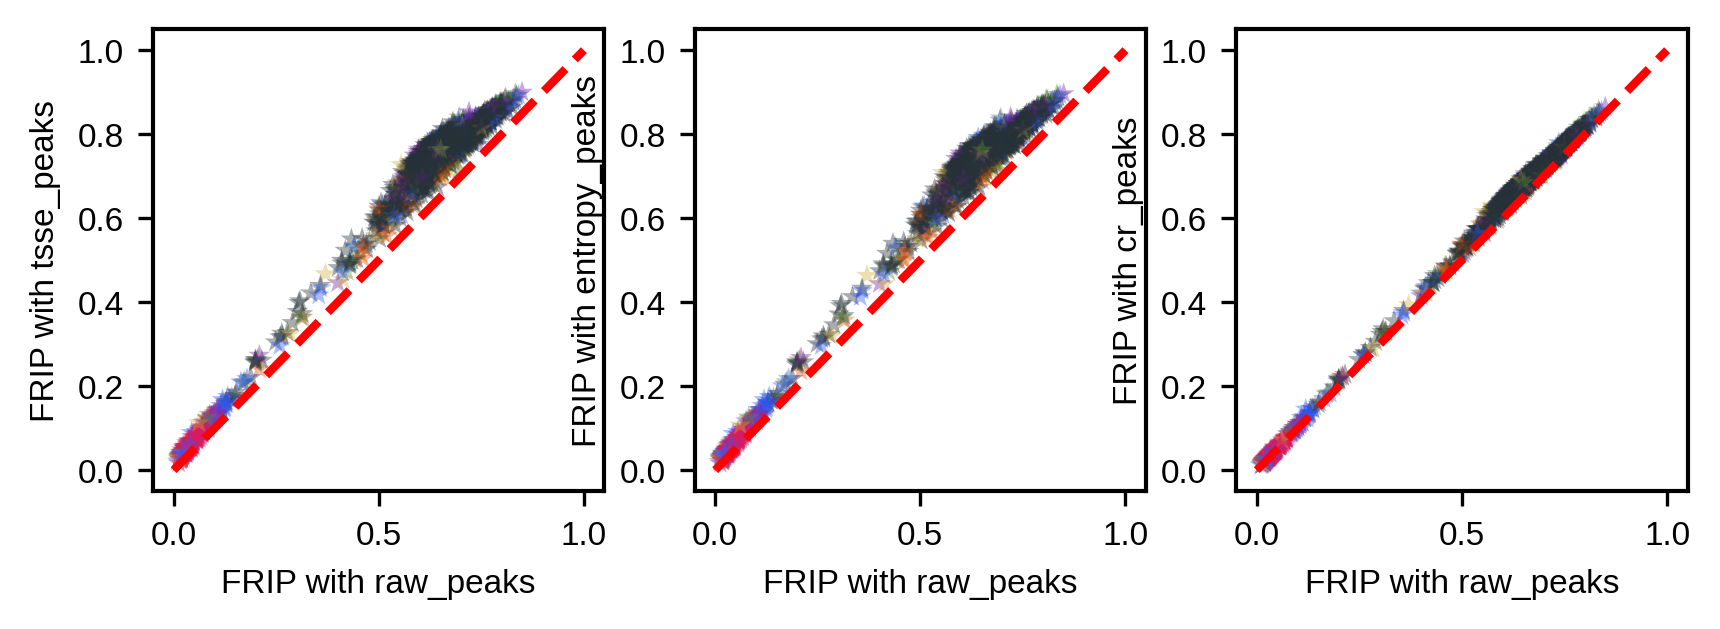

In [18]:
# wspace =0.3
fig, ax = plt.subplots(ncols=3, figsize=(6.6, 2))


for i, y in enumerate(['tsse_peaks', 'entropy_peaks', 'cr_peaks']):
    x = 'raw_peaks'
    
    ax[i].scatter(total_frag_per_bc[f'FRIP_{x}'], 
               total_frag_per_bc[f'FRIP_{y}'], 
               c =total_frag_per_bc['_3set_identified_by_atac'].map(cat_colors_map), cmap='Set1', alpha=0.4, s=30, marker='*', edgecolor='none',
               )
    
    ax[i].tick_params(axis='both', which='major', labelsize=8)
    ax[i].set_xlabel(f'FRIP with {x}', fontsize=8)
    ax[i].set_ylabel(f'FRIP with {y}', fontsize=8)

    ax[i].plot([0, 1], [0, 1],  color='red', linestyle='--', linewidth=2)

## 

# SADE vs CR 

<>:29: SyntaxWarning: invalid escape sequence '\D'
<>:30: SyntaxWarning: invalid escape sequence '\D'
<>:29: SyntaxWarning: invalid escape sequence '\D'
<>:30: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2874173/1829007326.py:29: SyntaxWarning: invalid escape sequence '\D'
  ax.set_xlabel('$\Delta$ $FRIP_{' + y1_label + '}$', )
/tmp/ipykernel_2874173/1829007326.py:30: SyntaxWarning: invalid escape sequence '\D'
  ax.set_ylabel('$\Delta$ $FRIP_{' + y2_label + '}$', )


----- Ratio of delta FRIP between CR and SADE peak sets -----
count    2375.000000
mean        3.575903
std         1.547665
min         1.875000
25%         3.080561
50%         3.246377
75%         3.476872
max        24.000000
dtype: float64


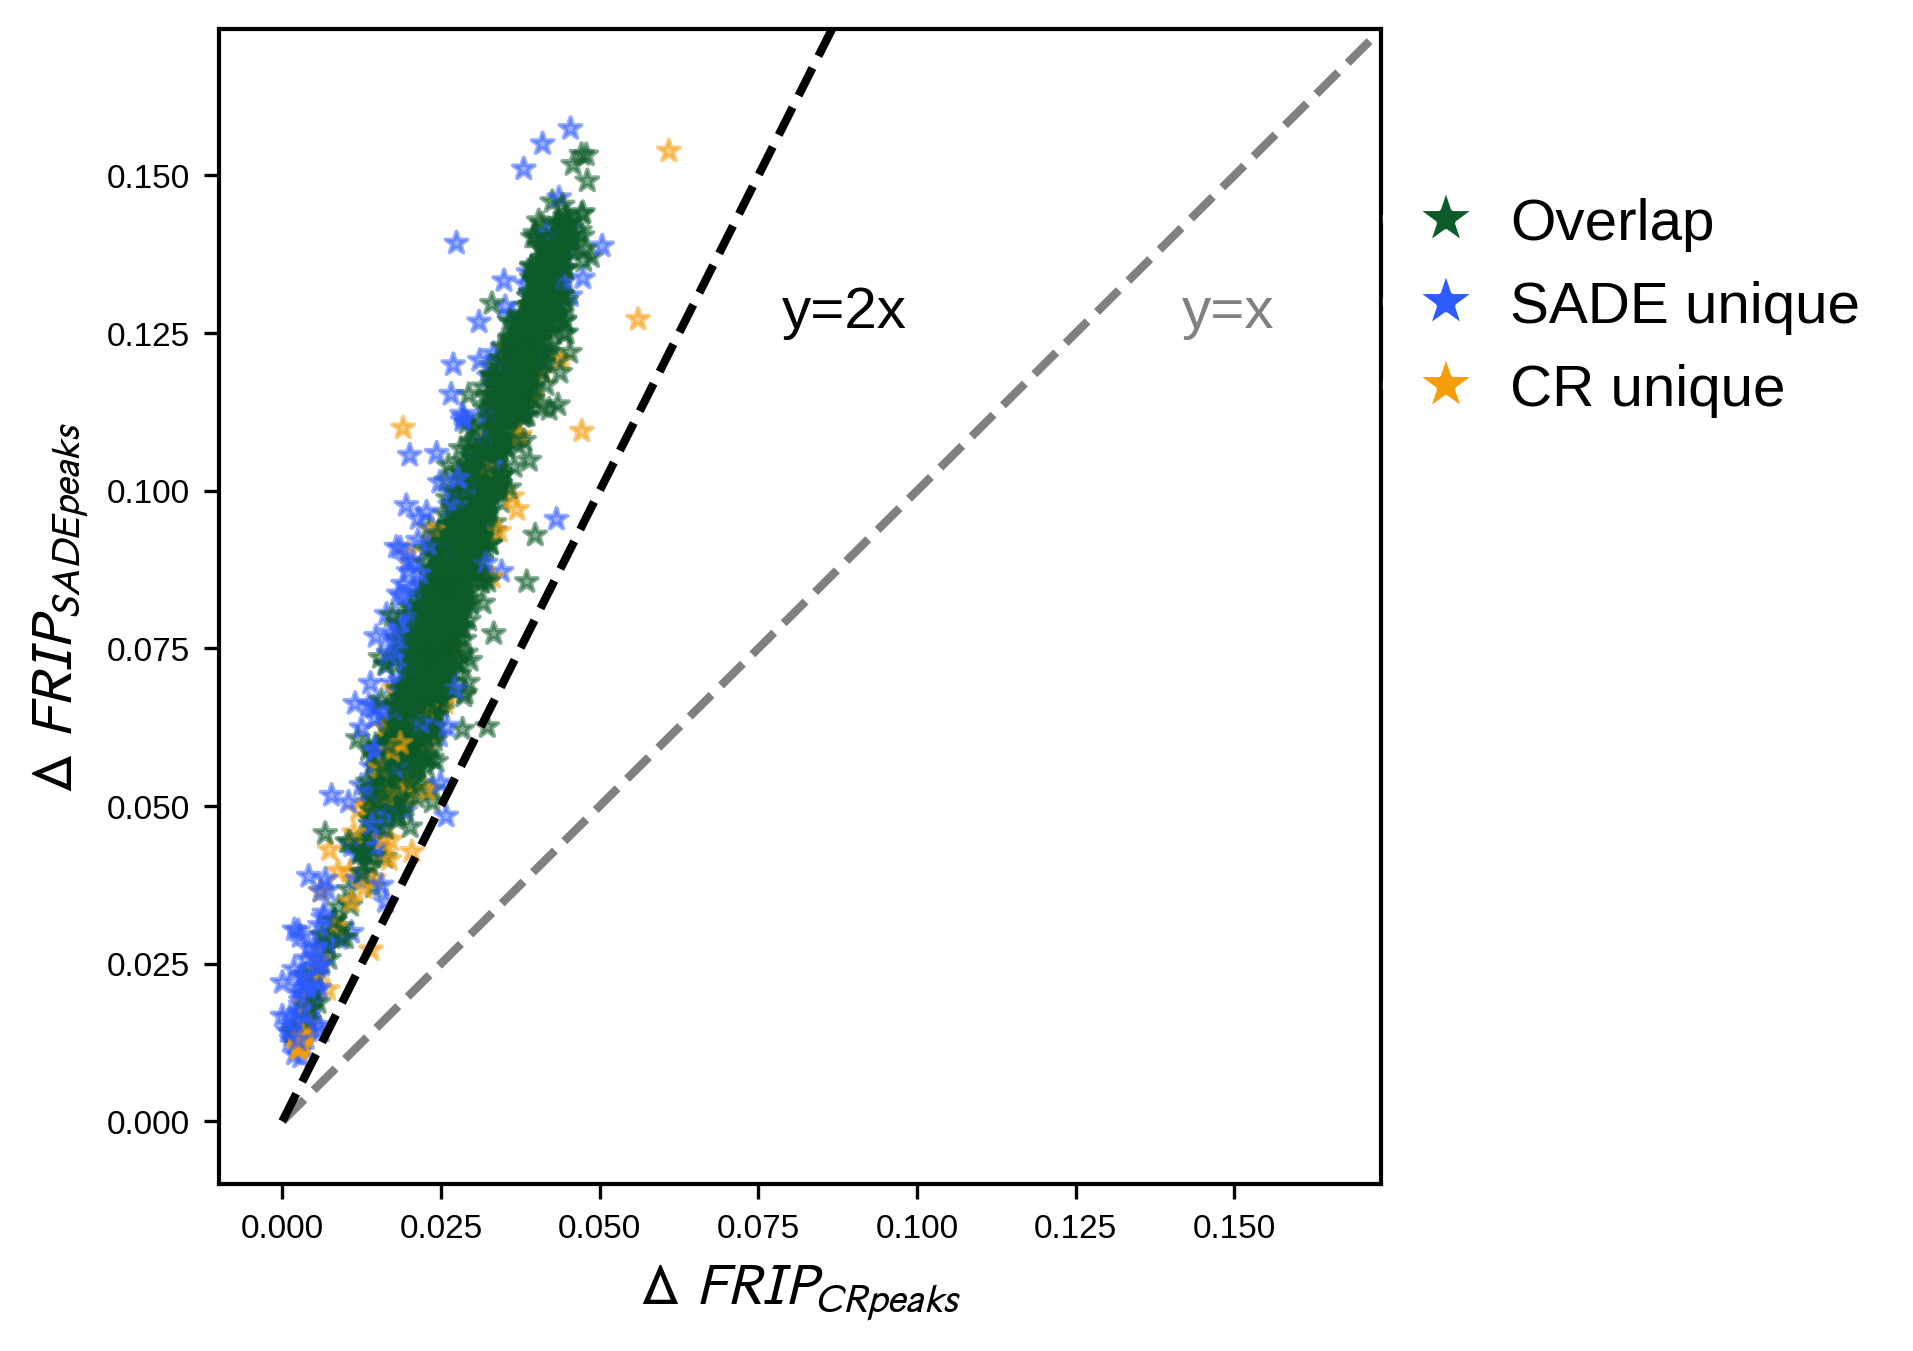

In [20]:
# wspace =0.3
fig= plt.figure(figsize=(6.6, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[0.2, 1])
ax = fig.add_subplot(gs[1])

y2 = 'entropy_peaks'
y1 = 'cr_peaks'
x = 'raw_peaks'

y1_label = ' CR peaks'
y2_label = ' SADE peaks'

tss_unique_index = total_frag_per_bc['_2set_identified_by_atac_SC_mod'] == 'tss_only'


delta_frip_y1 = total_frag_per_bc[f'FRIP_{y1}'] - total_frag_per_bc[f'FRIP_{x}']
delta_frip_y2 = total_frag_per_bc[f'FRIP_{y2}'] - total_frag_per_bc[f'FRIP_{x}']
max_range = max(delta_frip_y1.max(), delta_frip_y2.max())
# Clean droplets 
ax.scatter(delta_frip_y1[(~tss_unique_index) ], 
            delta_frip_y2[(~tss_unique_index)], 
            c=total_frag_per_bc.loc[(~tss_unique_index), '_2set_identified_by_atac_SC_mod'].map(SADEvsCR_colors_map), alpha=0.5, s=30, marker='*', 
            edgecolor=total_frag_per_bc.loc[(~tss_unique_index), '_2set_identified_by_atac_SC_mod'].map(SADEvsCR_colors_map)
            )

ax.tick_params(axis='both', which='major', labelsize=8)
ax.set_xlim(-0.01, max_range * 1.1)
ax.set_ylim(-0.01, max_range * 1.1)
ax.set_xlabel('$\Delta$ $FRIP_{' + y1_label + '}$', )
ax.set_ylabel('$\Delta$ $FRIP_{' + y2_label + '}$', )

line_points = np.array([0.0, max_range * 1.1])
ax.plot(line_points, line_points,  color='grey', linestyle='--', linewidth=2)
ax.plot(line_points, 2* line_points,  color='black', linestyle='--', linewidth=2)
ax.text(max_range*0.9, max_range*0.8, 'y=x',  color='grey')
ax.text(max_range*0.5, max_range*0.8, 'y=2x',  color='black')
handles = [Line2D([0], [0], marker='*', color='w' ,markersize=15, markerfacecolor=SADEvsCR_colors_map[cat], label=SADEvsCR_label_map[cat]) for cat in SADEvsCR_unique_categoris if cat not in ( 'none', 'tss_only')] 
ax.legend(handles=handles, frameon=False, title='', bbox_to_anchor=(.96, 0.9), handletextpad=0.1, loc='upper left')


fig.savefig(os.path.join(os.getcwd(), '_figures',  'fig3_p2.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(os.getcwd(), '_figures',  'fig3_p2.pdf'),  bbox_inches='tight')



print ('----- Ratio of delta FRIP between CR and SADE peak sets -----')
print( (delta_frip_y2 / delta_frip_y1).apply(lambda x: x if np.isfinite(x) else np.nan).describe())

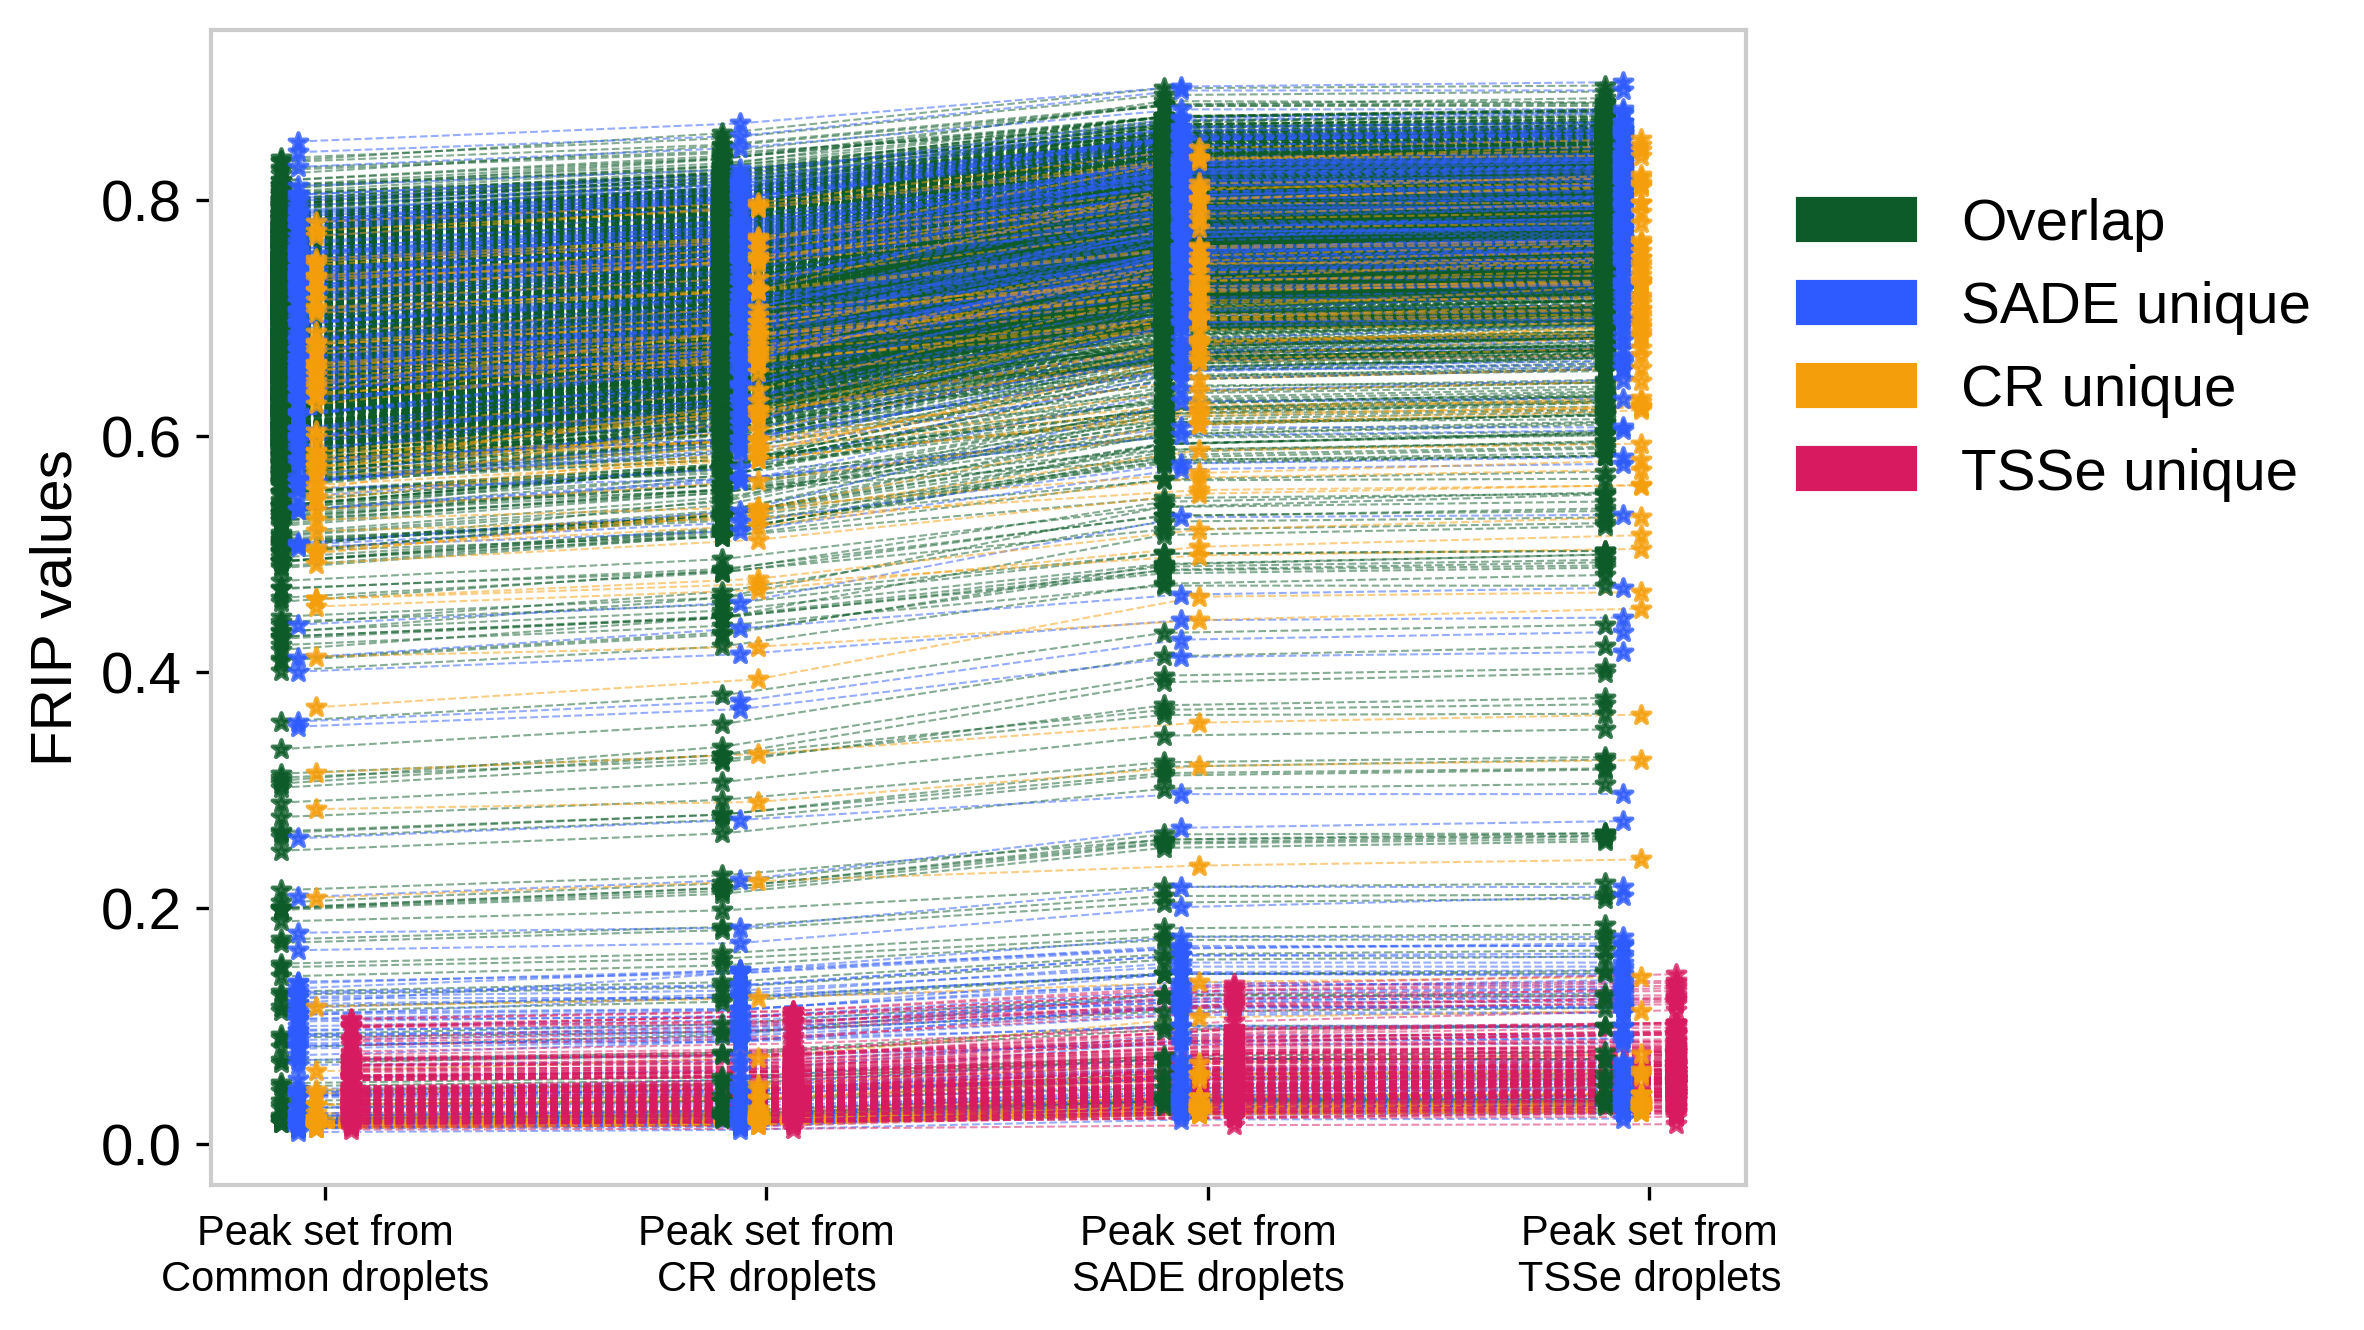

In [21]:
fig, ax = plt.subplots(ncols=1, figsize=(6.6, 5))

position_offset = 0.04 * (np.arange( len(SADEvsCR_unique_categoris)) -  len(SADEvsCR_unique_categoris)/2)  

_frip_col_names = ['FRIP_raw_peaks', 'FRIP_cr_peaks', 'FRIP_entropy_peaks', 'FRIP_tsse_peaks'] 

for i, cat in enumerate(SADEvsCR_unique_categoris):
    
    datapoints_index = total_frag_per_bc['_2set_identified_by_atac_SC_mod'] == cat
    color = SADEvsCR_colors_map[cat]
    frip_diff = total_frag_per_bc.loc[datapoints_index,  _frip_col_names] 
    _ = ax.plot(position_offset[i] + np.arange(len(frip_diff.T)), frip_diff.T, alpha=0.5, color=color,  markersize=4, linestyle='--', linewidth=0.5)
    N_datapoints = frip_diff.shape[0]
    for j, col in enumerate(_frip_col_names):
        _ = ax.scatter(np.repeat(position_offset[i] + j, N_datapoints), frip_diff.iloc[:, j], alpha=0.8, color=color, marker='*', s=20, zorder=3)

handles = [mpatches.Patch(color=SADEvsCR_colors_map[cat], label=SADEvsCR_label_map[cat]) for cat in SADEvsCR_unique_categoris if cat not in ( 'none')]
ax.legend(handles=handles, frameon=False, title='', bbox_to_anchor=(1., 0.9), loc='upper left')
ax.set_xticks(range(len(_frip_col_names)))
ax.set_xticklabels([frip_col_labels_map[col] for col in  _frip_col_names], rotation=0, ha='center', fontsize=10)
ax.set_ylabel('FRIP values')


for edge in ['top', 'right', 'left', 'bottom']:
    ax.spines[edge].set_color('#cccccc')


<>:35: SyntaxWarning: invalid escape sequence '\D'
<>:36: SyntaxWarning: invalid escape sequence '\D'
<>:35: SyntaxWarning: invalid escape sequence '\D'
<>:36: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2874173/1394705493.py:35: SyntaxWarning: invalid escape sequence '\D'
  ax.set_xlabel(f'$\Delta$ FRIP with {y1}', fontsize=8)
/tmp/ipykernel_2874173/1394705493.py:36: SyntaxWarning: invalid escape sequence '\D'
  ax.set_ylabel(f'$\Delta$ FRIP with {y2}', fontsize=8)


----- Ratio of delta FRIP between TSSe and SADE peak sets -----
count    2384.000000
mean        1.094769
std         0.082006
min         0.846154
25%         1.068839
50%         1.080724
75%         1.093088
max         2.500000
dtype: float64


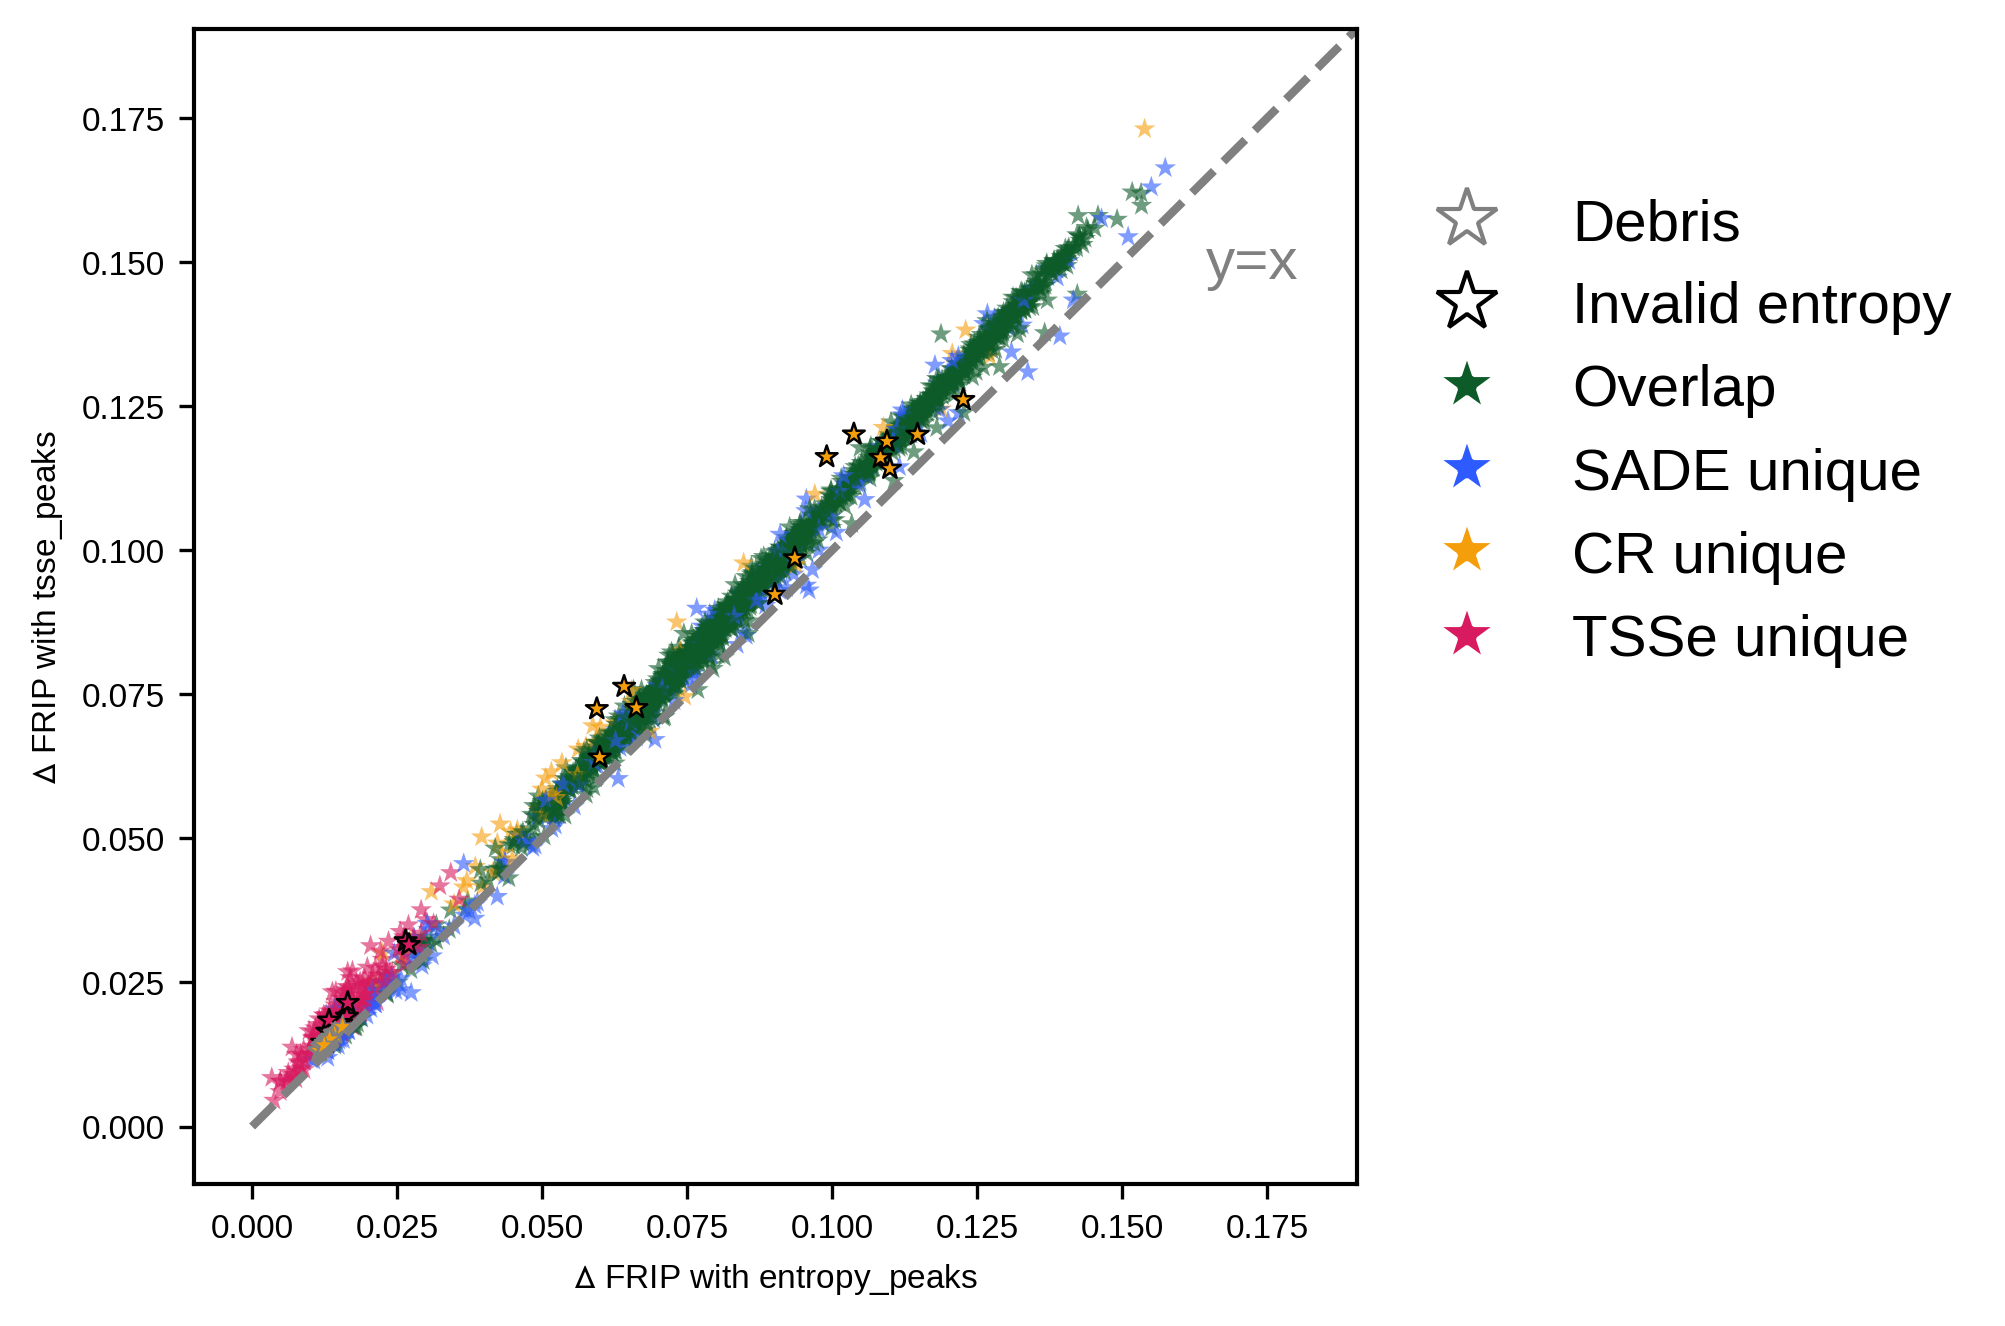

In [ ]:
# wspace =0.3
fig= plt.figure(figsize=(6.6, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[0.2, 1])
ax = fig.add_subplot(gs[1])

y2 = 'tsse_peaks'
y1 = 'entropy_peaks'
x = 'raw_peaks'

tss_unique_index = total_frag_per_bc['_2set_identified_by_atac_SC_mod'] == 'tss_only'
debris_index = total_frag_per_bc['DNA_debris'] == 'YES'
invalid_entropy_index = total_frag_per_bc['Entropy'].isna()

delta_frip_y1 = total_frag_per_bc[f'FRIP_{y1}'] - total_frag_per_bc[f'FRIP_{x}']
delta_frip_y2 = total_frag_per_bc[f'FRIP_{y2}'] - total_frag_per_bc[f'FRIP_{x}']
max_range = max(delta_frip_y1.max(), delta_frip_y2.max())
# Clean droplets 
ax.scatter(delta_frip_y1[  (~debris_index) & (~invalid_entropy_index)], 
            delta_frip_y2[ (~debris_index) & (~invalid_entropy_index)], 
            c=total_frag_per_bc.loc[ (~debris_index) & (~invalid_entropy_index), '_2set_identified_by_atac_SC_mod'].map(SADEvsCR_colors_map), alpha=0.6, s=30, marker='*', edgecolor='none',
            )
# # Invalid entropy droplets
ax.scatter(delta_frip_y1[  (invalid_entropy_index)], 
            delta_frip_y2[  (invalid_entropy_index)], 
            c=total_frag_per_bc.loc[  (invalid_entropy_index), '_2set_identified_by_atac_SC_mod'].map(SADEvsCR_colors_map), alpha=1, s=30, marker='*', edgecolor='black', lw=0.6,
            )
# Debris droplets
ax.scatter(delta_frip_y1[ (debris_index)], 
            delta_frip_y2[ (debris_index)], 
            c=total_frag_per_bc.loc[ (debris_index), '_2set_identified_by_atac_SC_mod'].map(SADEvsCR_colors_map), alpha=1, s=30, marker='*', edgecolor='grey', lw=0.4,
            )
ax.tick_params(axis='both', which='major', labelsize=8)
ax.set_xlim(-0.01, max_range * 1.1)
ax.set_ylim(-0.01, max_range * 1.1)
ax.set_xlabel(f'$\Delta$ FRIP with {y1}', fontsize=8)
ax.set_ylabel(f'$\Delta$ FRIP with {y2}', fontsize=8)

ax.plot([0.0, max_range * 1.1], [0.0, max_range * 1.1],  color='grey', linestyle='--', linewidth=2)
ax.text(max_range*0.95, max_range*0.85, 'y=x',  color='grey')
handles = [Line2D([0], [0], marker='*', color='w',  markeredgecolor='grey', markerfacecolor='none', label='Debris', markersize=15) ]
handles += [Line2D([0], [0], marker='*', color='w',  markeredgecolor='black', markerfacecolor='none', label='Invalid entropy', markersize=15) ]
handles += [Line2D([0], [0], marker='*', color='w' ,markersize=15, markerfacecolor=SADEvsCR_colors_map[cat], label=SADEvsCR_label_map[cat]) for cat in SADEvsCR_unique_categoris if cat not in ( 'none')] 
ax.legend(handles=handles, frameon=False, title='', bbox_to_anchor=(1., 0.9), loc='upper left')


print ('----- Ratio of delta FRIP between TSSe and SADE peak sets -----')
print( (delta_frip_y2 / delta_frip_y1).apply(lambda x: x if np.isfinite(x) else np.nan).describe())

In [23]:
debris_index.sum()

np.int64(22)

<>:35: SyntaxWarning: invalid escape sequence '\D'
<>:36: SyntaxWarning: invalid escape sequence '\D'
<>:35: SyntaxWarning: invalid escape sequence '\D'
<>:36: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2874173/357786384.py:35: SyntaxWarning: invalid escape sequence '\D'
  ax.set_xlabel(f'$\Delta$ FRIP with {y1}', fontsize=8)
/tmp/ipykernel_2874173/357786384.py:36: SyntaxWarning: invalid escape sequence '\D'
  ax.set_ylabel(f'$\Delta$ FRIP with {y2}', fontsize=8)


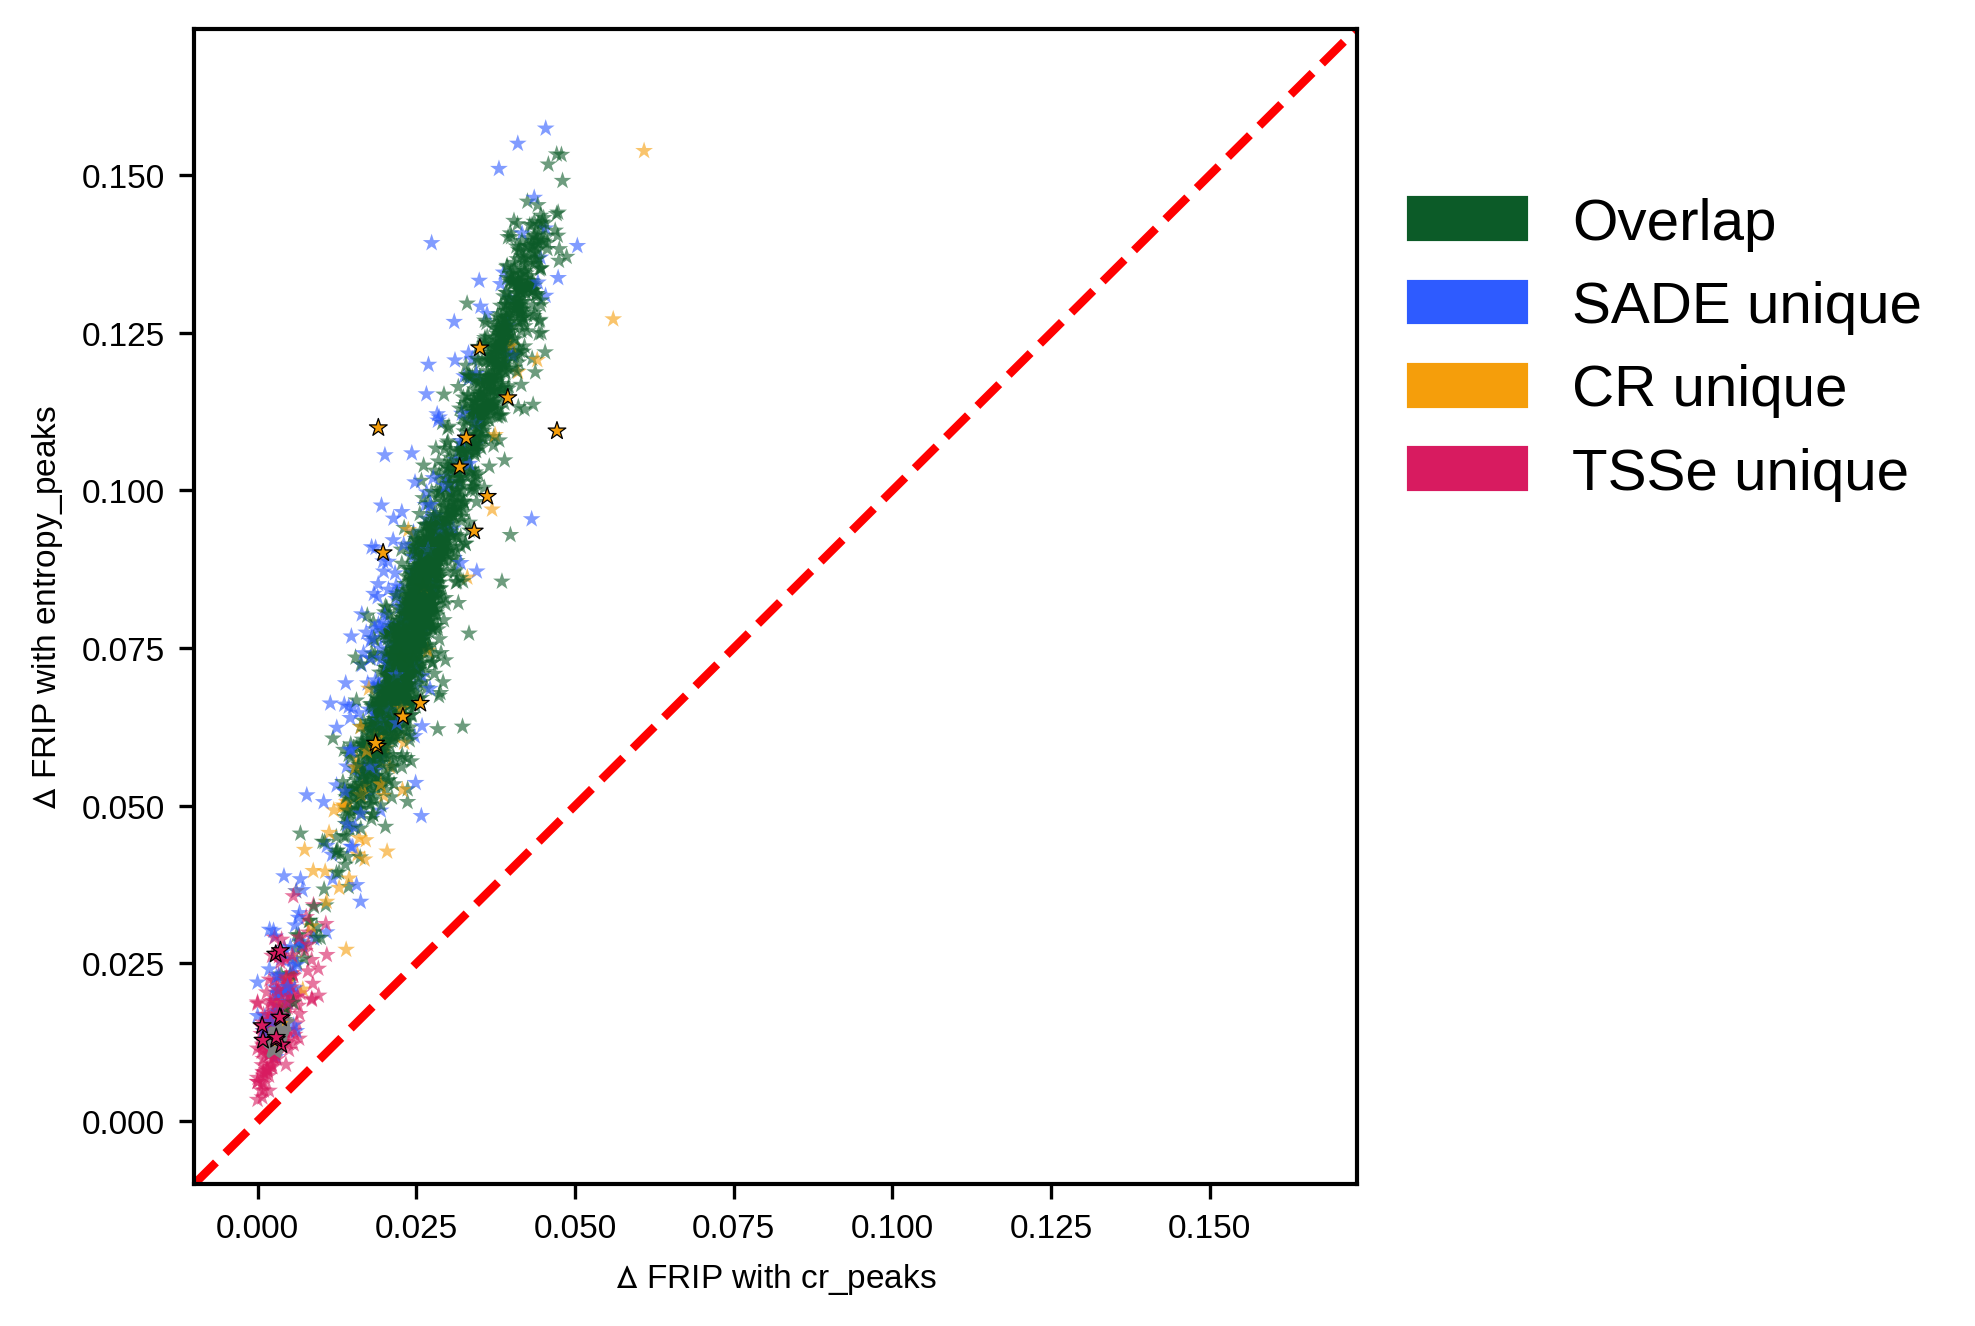

In [24]:
# wspace =0.3
fig= plt.figure(figsize=(6.6, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[0.2, 1])
ax = fig.add_subplot(gs[1])

y2 = 'entropy_peaks'
y1 = 'cr_peaks'
x = 'raw_peaks'

tss_unique_index = total_frag_per_bc['_2set_identified_by_atac_SC_mod'] == 'tss_only'
debris_index = total_frag_per_bc['DNA_debris'] == 'YES'
invalid_entropy_index = total_frag_per_bc['Entropy'].isna()

delta_frip_y1 = total_frag_per_bc[f'FRIP_{y1}'] - total_frag_per_bc[f'FRIP_{x}']
delta_frip_y2 = total_frag_per_bc[f'FRIP_{y2}'] - total_frag_per_bc[f'FRIP_{x}']
max_range = max(delta_frip_y1.max(), delta_frip_y2.max())
# Clean droplets 
ax.scatter(delta_frip_y1[  (~debris_index) & (~invalid_entropy_index)], 
            delta_frip_y2[ (~debris_index) & (~invalid_entropy_index)], 
            c=total_frag_per_bc.loc[ (~debris_index) & (~invalid_entropy_index), '_2set_identified_by_atac_SC_mod'].map(SADEvsCR_colors_map), alpha=0.6, s=20, marker='*', edgecolor='none',
            )
# Debris droplets
ax.scatter(delta_frip_y1[ (debris_index)], 
            delta_frip_y2[ (debris_index)], 
            c=total_frag_per_bc.loc[ (debris_index), '_2set_identified_by_atac_SC_mod'].map(SADEvsCR_colors_map), alpha=1, s=20, marker='*', edgecolor='grey', lw=0.7,
            )
# Invalid entropy droplets
ax.scatter(delta_frip_y1[  (invalid_entropy_index)], 
            delta_frip_y2[  (invalid_entropy_index)], 
            c=total_frag_per_bc.loc[  (invalid_entropy_index), '_2set_identified_by_atac_SC_mod'].map(SADEvsCR_colors_map), alpha=1, s=20, marker='*', edgecolor='black', lw=0.3,
            )
ax.tick_params(axis='both', which='major', labelsize=8)
ax.set_xlim(-0.01, max_range * 1.1)
ax.set_ylim(-0.01, max_range * 1.1)
ax.set_xlabel(f'$\Delta$ FRIP with {y1}', fontsize=8)
ax.set_ylabel(f'$\Delta$ FRIP with {y2}', fontsize=8)

ax.plot([-0.01, max_range * 1.1], [-0.01, max_range * 1.1],  color='red', linestyle='--', linewidth=2)
handles = [mpatches.Patch(color=SADEvsCR_colors_map[cat], label=SADEvsCR_label_map[cat]) for cat in SADEvsCR_unique_categoris if cat not in ( 'none')]
ax.legend(handles=handles, frameon=False, title='', bbox_to_anchor=(1., 0.9), loc='upper left')